# Vueling Contrail Avoidance Strategy
**MSc Sustainable Transport — Imperial College London**

This notebook quantifies:
1. Baseline total climate impact including contrail CO₂e (2025–2035)
2. The effect of implementing a contrail avoidance strategy from 2027

All contrail parameters are sourced from:
> Martin Frias et al. (2024). *Feasibility of contrail avoidance in a commercial flight planning system: an operational analysis.* Environ. Res.: Infrastruct. Sustain. 4, 015013.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.legend as mlegend
from matplotlib.patches import Patch

# ── Vueling design system ──────────────────────────────────────────────────────
VY = dict(
    yellow     = '#F5C800',
    dark       = '#1A1A1A',
    grey       = '#A0A0A0',
    light_grey = '#D6D6D6',
    white      = '#FFFFFF',
    bg         = '#F5F5F5',
    gold       = '#D4A017',
    teal       = '#00A3A6',
    deep_teal  = '#00657A',
    purple     = '#7B4FA6',
)

IC = dict(
    navy='#002147', plum='#3E1060', violet='#653098',
    lavender='#9B59D0', lilac='#C9A6E8', ice='#EEEEEE',
    deep_teal='#00657A', teal='#00A3A6', gold='#D4A017',
    fog='#F5F5F5', ink='#1A1A1A', mid='#A0A0A0',
)

plt.rcParams.update({
    'figure.facecolor'   : VY['bg'],
    'axes.facecolor'     : VY['bg'],
    'axes.edgecolor'     : VY['light_grey'],
    'axes.linewidth'     : 0.8,
    'axes.grid'          : True,
    'grid.color'         : '#E0E0E0',
    'grid.linewidth'     : 0.6,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'text.color'         : VY['dark'],
    'axes.labelcolor'    : VY['dark'],
    'xtick.color'        : VY['grey'],
    'ytick.color'        : VY['grey'],
    'font.family'        : 'Arial',
    'axes.titleweight'   : 'bold',
    'axes.titlesize'     : 13,
    'axes.labelsize'     : 10,
    'axes.labelweight'   : 'bold',
    'axes.labelpad'      : 8,
    'legend.framealpha'  : 0.95,
    'legend.edgecolor'   : VY['light_grey'],
    'figure.dpi'         : 150,
})

_legend_init_orig = mlegend.Legend.__init__
def _legend_init_bold(self, *args, **kwargs):
    _legend_init_orig(self, *args, **kwargs)
    if self.get_title().get_text():
        self.get_title().set_fontweight('bold')
mlegend.Legend.__init__ = _legend_init_bold

def styled_title(fig, title, subtitle=None, y_pad=0.05):
    y = 0.98 if subtitle else 0.96
    fig.text(0.5, y, title, ha='center', va='top', fontsize=15,
             fontweight='bold', color=VY['dark'])
    if subtitle:
        fig.text(0.5, y - y_pad, subtitle, ha='center', va='top', fontsize=9,
                 color=VY['grey'], fontstyle='italic')

def style_legend(leg, edge_color=None):
    edge_color = edge_color or VY['yellow']
    leg.get_frame().set_edgecolor(edge_color)
    leg.get_frame().set_facecolor(VY['bg'])
    leg.get_title().set_fontweight('bold')
    leg.get_title().set_color(VY['dark'])

def watermark(fig):
    fig.text(0.99, 0.01, 'Vueling Climate Strategy · Imperial College London',
             ha='right', va='bottom', fontsize=6, color=VY['grey'], style='italic')

print('Design system loaded ✓')

Design system loaded ✓


## 1 — Parameters
All contrail values sourced from Martin Frias et al. (2024) unless noted.

In [2]:
# ── Contrail warming ratio (GWP₂₀) ───────────────────────────────────────────
# Source: Table 2, Martin Frias et al. (2024)
# Contrail CO₂e,20 = 0.906 Mt, Direct CO₂ = 2.086 Mt  →  ratio = 0.906 / 2.086 = 0.4343
# Uses EF framework with ERF/RF correction factor of 0.42 and AGWP_CO2 over 20yr horizon.
CONTRAIL_GWP20_RATIO  = 0.4343

# Source: Table 5, Martin Frias et al. (2024)
# Contrail CO₂e,100 = 0.247 Mt, Direct CO₂ = 2.086 Mt  →  ratio = 0.247 / 2.086 = 0.1184
CONTRAIL_GWP100_RATIO = 0.1184

# ── Avoidance effectiveness ───────────────────────────────────────────────────
# Source: Table 2, Martin Frias et al. (2024)
# Total EF_contrail reduced by 72.95% after full re-optimisation of warming flights
AVOIDANCE_EFFECTIVENESS = 0.7295

# ── Fuel penalty from avoidance ───────────────────────────────────────────────
# Source: Table 2, Martin Frias et al. (2024)
# Total fleet fuel increased +0.11% after avoidance.
# Applied to all flights (aggregate approach): same final CO₂ increase regardless
# of whether you model it per-rerouted-flight or fleet-wide.
FUEL_PENALTY_TOTAL = 0.0011

# ── Deployment ────────────────────────────────────────────────────────────────
AVOIDANCE_START_YEAR = 2027   # fully deployed from this year, no ramp-up

# ── Time horizon ──────────────────────────────────────────────────────────────
TIME_HORIZON   = 20           # switch to 100 for GWP₁₀₀ — all calculations update
CONTRAIL_RATIO = CONTRAIL_GWP20_RATIO if TIME_HORIZON == 20 else CONTRAIL_GWP100_RATIO

print(f'Parameters loaded ✓')
print(f'  Time horizon        : GWP{TIME_HORIZON}')
print(f'  Contrail ratio      : {CONTRAIL_RATIO:.4f}  (contrail CO₂e = direct CO₂ × this)')
print(f'  Avoidance from      : {AVOIDANCE_START_YEAR}')
print(f'  EF_contrail reduced : {AVOIDANCE_EFFECTIVENESS*100:.2f}%')
print(f'  Fuel penalty        : +{FUEL_PENALTY_TOTAL*100:.2f}% on total fleet CO₂')

Parameters loaded ✓
  Time horizon        : GWP20
  Contrail ratio      : 0.4343  (contrail CO₂e = direct CO₂ × this)
  Avoidance from      : 2027
  EF_contrail reduced : 72.95%
  Fuel penalty        : +0.11% on total fleet CO₂


## 2 — Load & aggregate forecast data

In [3]:
DATA_PATH = '../0. Data/1 Year Flight Data/vueling_historical_and_forecast.csv'

df = pd.read_csv(DATA_PATH)

# Parse year from year_month column (format: '2025-02')
df['year'] = df['year_month'].str[:4].astype(int)

# Keep forecast period 2025-2035 only
df = df[df['year'].between(2025, 2035)]

# Aggregate annually — sum across all aircraft types per year
annual = (
    df.groupby('year')
    .agg(
        flights      = ('flights_count',        'sum'),
        distance_km  = ('total_distance_km_sum', 'sum'),
        LTO_CO2_kg   = ('LTO_CO2_sum',           'sum'),
        CCD_CO2_kg   = ('CCD_CO2_sum',           'sum'),
        Total_CO2_kg = ('Total_CO2_sum',          'sum'),
    )
    .reset_index()
)

# Convert kg → Mt
annual['CO2_Mt'] = annual['Total_CO2_kg'] / 1e9

print(annual[['year', 'flights', 'CO2_Mt']].to_string(index=False))

 year   flights   CO2_Mt
 2025 205498.00 2.622306
 2026 239402.31 3.066407
 2027 247517.56 3.170150
 2028 256033.32 3.260690
 2029 265849.85 3.364566
 2030 276293.88 3.473531
 2031 286419.92 3.577512
 2032 297716.49 3.696269
 2033 309052.30 3.812627
 2034 320056.48 3.917187
 2035 331462.70 4.019255


## 3 — Calculate contrail scenarios

In [4]:
# ── Scenario A: Direct CO₂ only (no contrail accounting) ─────────────────────
annual['CO2_only_Mt'] = annual['CO2_Mt']

# ── Scenario B: Baseline — direct CO₂ + contrail warming, no avoidance ────────
# Contrail CO₂e = direct CO₂ × CONTRAIL_RATIO
annual['contrail_CO2e_Mt']      = annual['CO2_Mt'] * CONTRAIL_RATIO
annual['total_no_avoidance_Mt'] = annual['CO2_Mt'] + annual['contrail_CO2e_Mt']

# ── Scenario C: With contrail avoidance from AVOIDANCE_START_YEAR ─────────────
annual['avoidance_active'] = annual['year'] >= AVOIDANCE_START_YEAR

# Direct CO₂ increases slightly (fuel penalty on rerouted flights)
annual['CO2_with_penalty_Mt'] = np.where(
    annual['avoidance_active'],
    annual['CO2_Mt'] * (1 + FUEL_PENALTY_TOTAL),
    annual['CO2_Mt']
)

# Contrail warming residual after avoidance
annual['contrail_residual_Mt'] = np.where(
    annual['avoidance_active'],
    annual['contrail_CO2e_Mt'] * (1 - AVOIDANCE_EFFECTIVENESS),
    annual['contrail_CO2e_Mt']
)

# Total warming with avoidance
annual['total_with_avoidance_Mt'] = annual['CO2_with_penalty_Mt'] + annual['contrail_residual_Mt']

# Warming avoided annually (only positive from avoidance years)
annual['warming_avoided_Mt'] = (
    annual['total_no_avoidance_Mt'] - annual['total_with_avoidance_Mt']
).clip(lower=0)

cols = ['year','CO2_Mt','contrail_CO2e_Mt','total_no_avoidance_Mt',
        'CO2_with_penalty_Mt','contrail_residual_Mt','total_with_avoidance_Mt','warming_avoided_Mt']
print(annual[cols].round(4).to_string(index=False))

 year  CO2_Mt  contrail_CO2e_Mt  total_no_avoidance_Mt  CO2_with_penalty_Mt  contrail_residual_Mt  total_with_avoidance_Mt  warming_avoided_Mt
 2025  2.6223            1.1389                 3.7612               2.6223                1.1389                   3.7612              0.0000
 2026  3.0664            1.3317                 4.3981               3.0664                1.3317                   4.3981              0.0000
 2027  3.1702            1.3768                 4.5469               3.1736                0.3724                   3.5461              1.0009
 2028  3.2607            1.4161                 4.6768               3.2643                0.3831                   3.6473              1.0295
 2029  3.3646            1.4612                 4.8258               3.3683                0.3953                   3.7635              1.0623
 2030  3.4735            1.5086                 4.9821               3.4774                0.4081                   3.8854              1.0967

## 4 — C1: Total climate impact — no avoidance vs with avoidance (stacked bars)

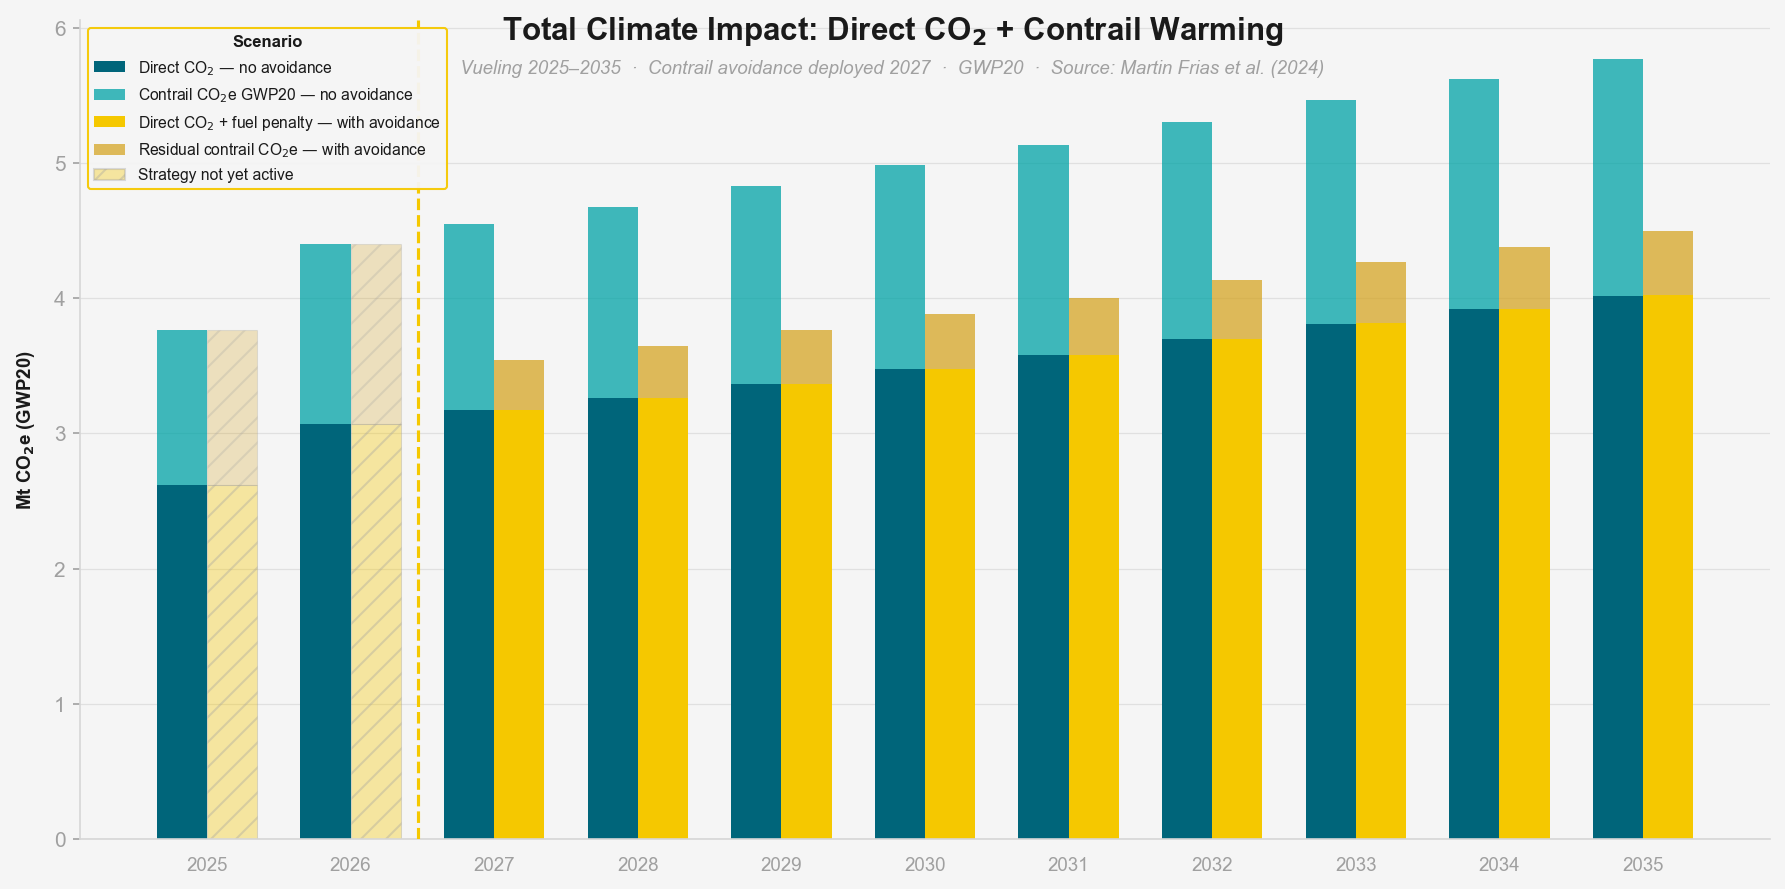

Saved → C1_contrail_strategy_202_fleet.pdf


In [ ]:
years = annual['year'].values
x     = np.arange(len(years))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# ── Left bars: no avoidance ───────────────────────────────────────────────────
ax.bar(x - bar_w/2, annual['CO2_Mt'], bar_w,
       color=VY['deep_teal'], zorder=2)
ax.bar(x - bar_w/2, annual['contrail_CO2e_Mt'], bar_w,
       bottom=annual['CO2_Mt'], color=VY['teal'], alpha=0.75, zorder=2)

# ── Right bars: with avoidance ────────────────────────────────────────────────
pre  = ~annual['avoidance_active'].values
post =  annual['avoidance_active'].values

# Pre-avoidance years — hatched, muted (strategy not yet active)
ax.bar(x[pre] + bar_w/2, annual['CO2_Mt'].values[pre], bar_w,
       color=VY['yellow'], alpha=0.35, zorder=2,
       hatch='//', edgecolor=VY['grey'], linewidth=0.5)
ax.bar(x[pre] + bar_w/2, annual['contrail_CO2e_Mt'].values[pre], bar_w,
       bottom=annual['CO2_Mt'].values[pre],
       color=VY['gold'], alpha=0.25, zorder=2,
       hatch='//', edgecolor=VY['grey'], linewidth=0.5)

# Post-avoidance years — full colour
ax.bar(x[post] + bar_w/2, annual['CO2_with_penalty_Mt'].values[post], bar_w,
       color=VY['yellow'], zorder=2)
ax.bar(x[post] + bar_w/2, annual['contrail_residual_Mt'].values[post], bar_w,
       bottom=annual['CO2_with_penalty_Mt'].values[post],
       color=VY['gold'], alpha=0.7, zorder=2)

# ── Deployment divider ────────────────────────────────────────────────────────
start_x = np.where(years == AVOIDANCE_START_YEAR)[0][0]
ax.axvline(start_x - bar_w - 0.18, color=VY['yellow'],
           linewidth=1.5, linestyle='--', zorder=3)
# ax.text(start_x - bar_w - 0.22,
#         annual['total_no_avoidance_Mt'].max() * 0.98,
#         f'Strategy\ndeployed\n{AVOIDANCE_START_YEAR}',
#         ha='right', va='top', fontsize=7.5, color=VY['dark'],
#         bbox=dict(facecolor=VY['bg'], edgecolor=VY['yellow'], pad=3, lw=0.8))

# ── Grid & spines ─────────────────────────────────────────────────────────────
ax.set_axisbelow(True)
ax.grid(True, axis='y', zorder=0)
ax.grid(False, axis='x')
ax.spines['left'].set_color(VY['light_grey'])
ax.spines['bottom'].set_color(VY['light_grey'])

ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=9)
ax.tick_params(axis='x', length=0, pad=8)
ax.set_ylabel(rf'Mt CO$\mathbf{{_2}}$e (GWP{TIME_HORIZON})', fontsize=9)

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    Patch(facecolor=VY['deep_teal'], label=r'Direct CO$_2$ — no avoidance'),
    Patch(facecolor=VY['teal'], alpha=0.75, label=f'Contrail CO$_2$e GWP{TIME_HORIZON} — no avoidance'),
    Patch(facecolor=VY['yellow'], label=r'Direct CO$_2$ + fuel penalty — with avoidance'),
    Patch(facecolor=VY['gold'], alpha=0.7, label=r'Residual contrail CO$_2$e — with avoidance'),
    Patch(facecolor=VY['yellow'], alpha=0.35, hatch='//', edgecolor=VY['grey'],
          label='Strategy not yet active'),
]

leg = ax.legend(handles=handles, title='Scenario', loc='upper left',
                fontsize=7.5, title_fontsize=8)
style_legend(leg)

styled_title(fig,
    r'Total Climate Impact: Direct CO$\mathbf{_2}$ + Contrail Warming',
    f'Vueling 2025–2035  ·  Contrail avoidance deployed {AVOIDANCE_START_YEAR}  ·  GWP{TIME_HORIZON}  ·  Source: Martin Frias et al. (2024)')

# watermark(fig)
plt.tight_layout()
plt.savefig('../0. Data/Figures/C1_contrail_strategy_202_fleet.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → C1_contrail_strategy_202_fleet.pdf')

## 5 — C2: Warming avoided annually + cumulative

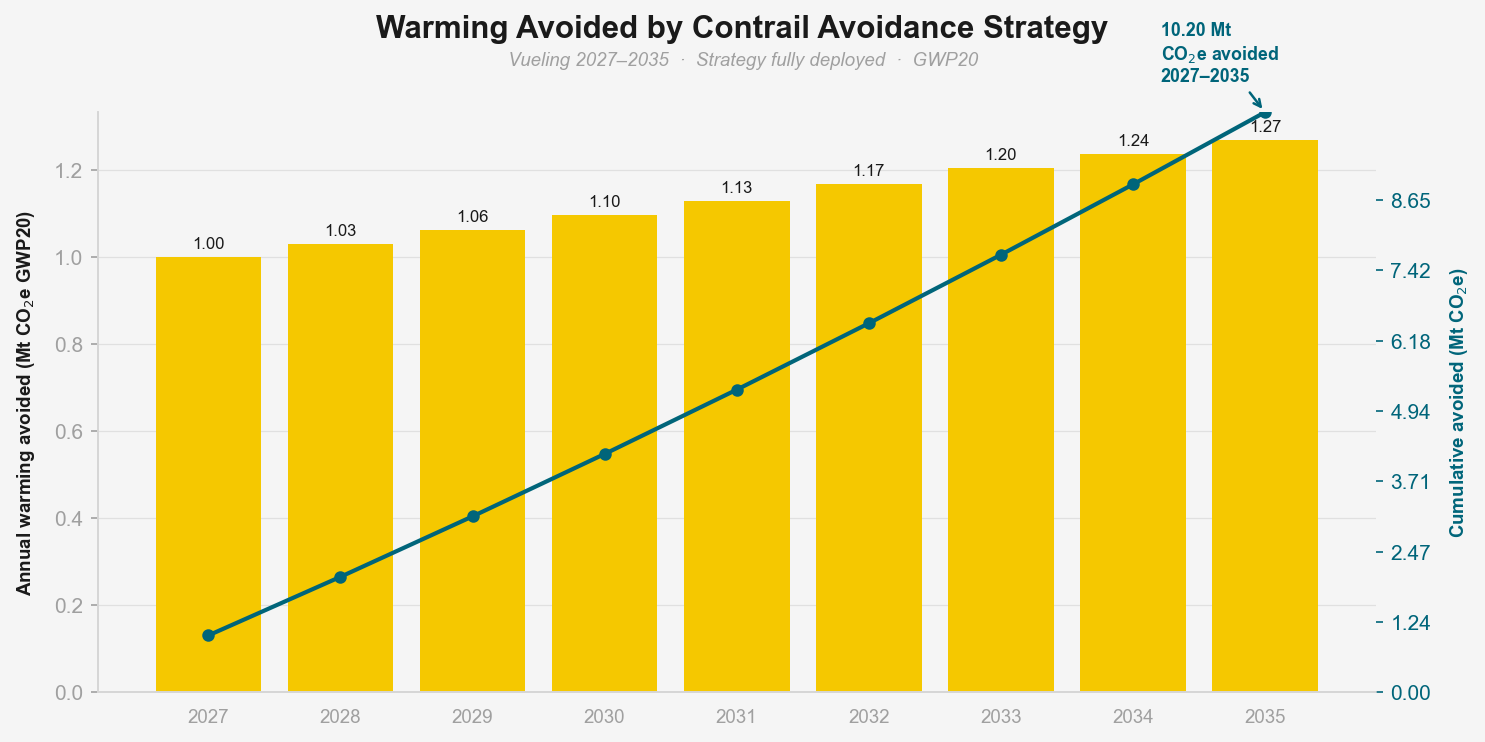

Saved → C2_warming_avoided.pdf


In [ ]:
avoided = annual[annual['avoidance_active']].copy().reset_index(drop=True)
x_av    = np.arange(len(avoided))

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(x_av, avoided['warming_avoided_Mt'], color=VY['yellow'], zorder=2)

# Value labels on bars
for bar, val in zip(bars, avoided['warming_avoided_Mt']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + avoided['warming_avoided_Mt'].max() * 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8, color=VY['dark'])

# Cumulative on twin axis
ax2 = ax.twinx()
cumulative = avoided['warming_avoided_Mt'].cumsum()

# Scale cumulative to share left axis range
left_max  = avoided['warming_avoided_Mt'].max() * 1.3   # matches left ylim after bars
cum_max   = cumulative.max()
scale     = left_max / cum_max
cum_scaled = cumulative * scale

ax2.plot(x_av, cum_scaled, color=VY['deep_teal'],
         linewidth=2, marker='o', markersize=5, zorder=3)

# Right axis ticks: show true cumulative values, not scaled ones
ax2.set_ylim(ax.get_ylim()[0], left_max)
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels([f'{t / scale:.2f}' if t >= 0 else '' for t in ax.get_yticks()])
ax2.set_ylabel(r'Cumulative avoided (Mt CO$_2$e)', fontsize=9, color=VY['deep_teal'])
ax2.tick_params(axis='y', colors=VY['deep_teal'])
ax2.spines['right'].set_color(VY['deep_teal'])
ax2.spines['left'].set_color(VY['light_grey'])
ax2.spines['bottom'].set_color(VY['light_grey'])
ax2.spines['top'].set_visible(False)
ax2.yaxis.grid(False)

ax2.annotate(
    f"{cumulative.iloc[-1]:.2f} Mt\nCO$_2$e avoided\n{AVOIDANCE_START_YEAR}–2035",
    xy=(x_av[-1], cum_scaled.iloc[-1]),
    xytext=(-50, 15), textcoords='offset points',
    fontsize=8.5, color=VY['deep_teal'], fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=VY['deep_teal'], lw=1.2)
)

# ── Grid & spines ─────────────────────────────────────────────────────────────
ax.set_axisbelow(True)
ax.grid(True, axis='y', zorder=0)
ax.grid(False, axis='x')
ax.spines['left'].set_color(VY['light_grey'])
ax.spines['bottom'].set_color(VY['light_grey'])
ax.spines['top'].set_visible(False)

ax.set_xticks(x_av)
ax.set_xticklabels(avoided['year'].values, fontsize=9)
ax.tick_params(axis='x', length=0, pad=8)
ax.set_ylabel(f'Annual warming avoided (Mt CO$_2$e GWP{TIME_HORIZON})', fontsize=9)

styled_title(fig,
    r'Warming Avoided by Contrail Avoidance Strategy',
    f'Vueling {AVOIDANCE_START_YEAR}–2035  ·  Strategy fully deployed  ·  GWP{TIME_HORIZON}')

plt.tight_layout()
plt.savefig('../0. Data/Figures/C2_warming_avoided_202_fleet.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → C2_warming_avoided.pdf')

## 6 — C3: Total warming timeline — three scenarios

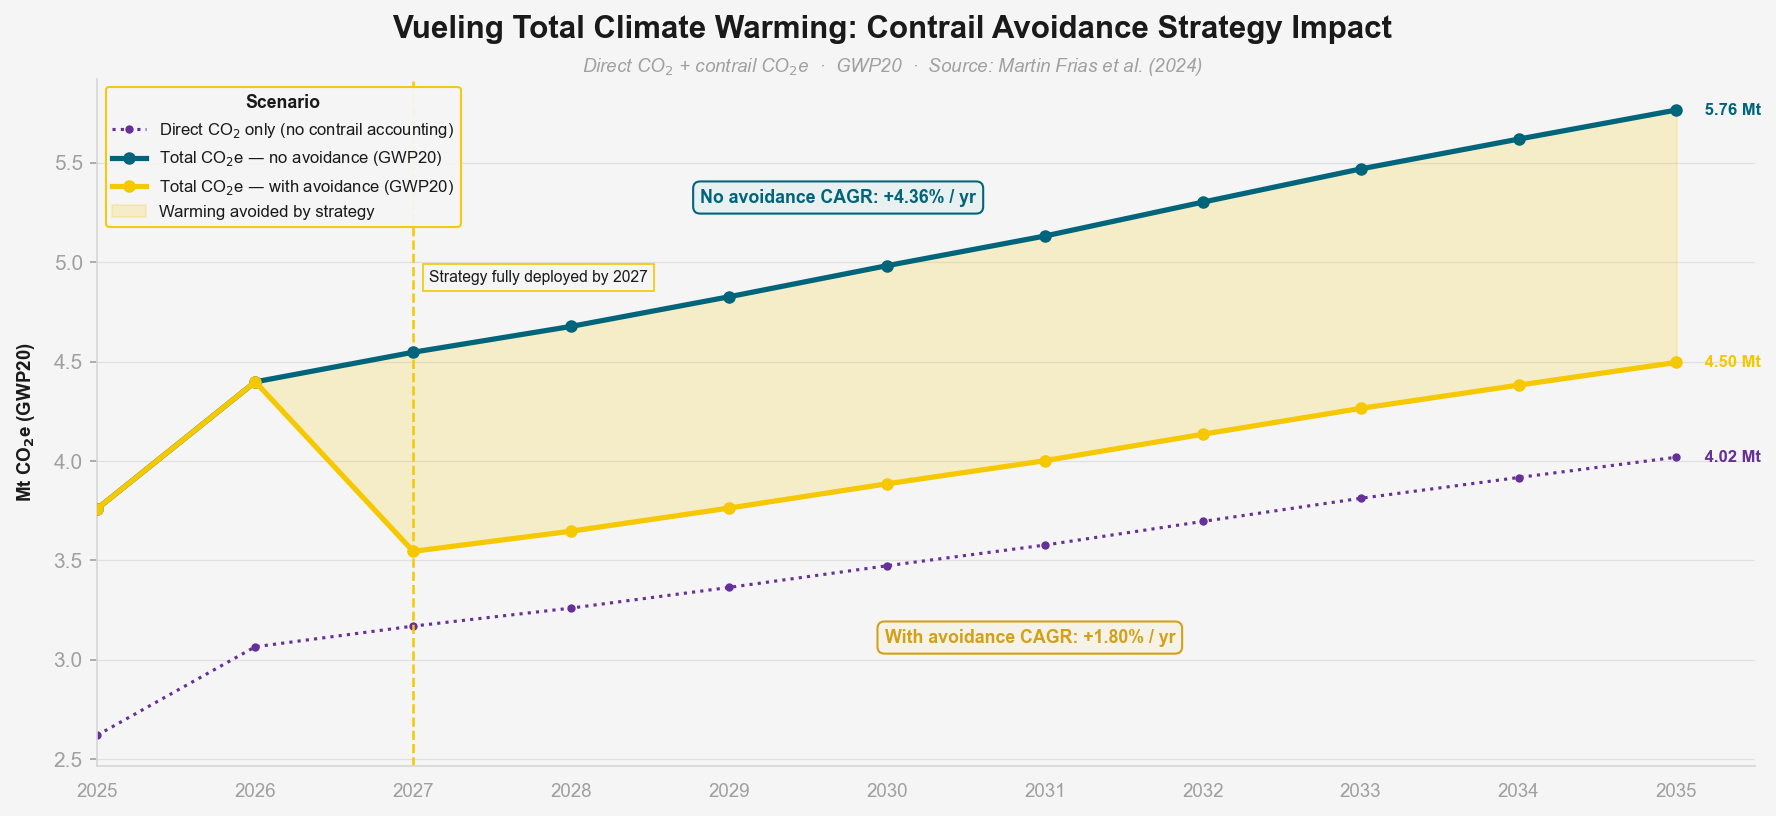

Saved → C3_warming_timeline.pdf


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5.5))

# Direct CO₂ only (reference, dotted)
ax.plot(years, annual['CO2_only_Mt'],
        color=IC['violet'], linewidth=1.5, linestyle=':', marker='.', zorder=2,
        label=r'Direct CO$_2$ only (no contrail accounting)')

# No avoidance total
ax.plot(years, annual['total_no_avoidance_Mt'],
        color=VY['deep_teal'], linewidth=2.5, marker='o', ms=5, zorder=3,
        label=f'Total CO$_2$e — no avoidance (GWP{TIME_HORIZON})')
# ax.fill_between(years,
#                 annual['CO2_only_Mt'], annual['total_no_avoidance_Mt'],
#                 color=VY['teal'], alpha=0.10, zorder=1)

# With avoidance total
ax.plot(years, annual['total_with_avoidance_Mt'],
        color=VY['yellow'], linewidth=2.5, marker='o', ms=5, zorder=3,
        label=f'Total CO$_2$e — with avoidance (GWP{TIME_HORIZON})')

# Gap fill = warming avoided
ax.fill_between(years,
                annual['total_with_avoidance_Mt'], annual['total_no_avoidance_Mt'],
                color=VY['yellow'], alpha=0.18, zorder=1,
                label='Warming avoided by strategy')

# Deployment line
ax.axvline(AVOIDANCE_START_YEAR, color=VY['yellow'],
           linewidth=1.2, linestyle='--', zorder=2)
ymax = annual['total_no_avoidance_Mt'].max()
ax.text(AVOIDANCE_START_YEAR + 0.1, ymax * 0.85,
        f'Strategy fully deployed by {AVOIDANCE_START_YEAR}',
        fontsize=7.5, color=VY['dark'],
        bbox=dict(facecolor=VY['bg'], edgecolor=VY['yellow'], pad=3, lw=0.8))

# 2035 end labels
for col, color in [
    ('total_no_avoidance_Mt',   VY['deep_teal']),
    ('total_with_avoidance_Mt', VY['yellow']),
    ('CO2_only_Mt',             IC['violet']),
]:
    val = annual[col].iloc[-1]
    ax.text(2035.15, val, f' {val:.2f} Mt',
            va='center', fontsize=8, color=color, fontweight='bold')

# CAGR boxes
cagr_no_av = (annual['total_no_avoidance_Mt'].iloc[-1] /
              annual['total_no_avoidance_Mt'].iloc[0]) ** (1/10) - 1
cagr_av    = (annual['total_with_avoidance_Mt'].iloc[-1] /
              annual['total_with_avoidance_Mt'].iloc[0]) ** (1/10) - 1

ax.annotate(f"No avoidance CAGR: {cagr_no_av:+.2%} / yr",
            xy=(0.53, 0.82), xycoords='axes fraction',
            ha='right', fontsize=8.5, color=VY['deep_teal'], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor=(*mcolors.to_rgb(IC['teal']), 0.05),
                      edgecolor=VY['deep_teal'], lw=1))
ax.annotate(f"With avoidance CAGR: {cagr_av:+.2%} / yr",
            xy=(0.65, 0.18), xycoords='axes fraction',
            ha='right', fontsize=8.5, color=VY['gold'], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor=(*mcolors.to_rgb(VY['yellow']), 0.05),
                      edgecolor=VY['gold'], lw=1))

ax.set_axisbelow(True)
ax.grid(True, axis='y', zorder=0)
ax.grid(False, axis='x')
ax.spines['left'].set_color(VY['light_grey'])
ax.spines['bottom'].set_color(VY['light_grey'])

ax.set_xlim(2025, 2035.5)
ax.set_xticks(years)
ax.set_xticklabels(years, fontsize=9)
ax.tick_params(axis='x', length=0, pad=8)
ax.set_ylabel(rf'Mt CO$\mathbf{{_2}}$e (GWP{TIME_HORIZON})', fontsize=9)

leg = ax.legend(loc='upper left', fontsize=8,
                title='Scenario', title_fontsize=8.5, bbox_to_anchor=(0, 1))
style_legend(leg)

styled_title(fig,
    r'Vueling Total Climate Warming: Contrail Avoidance Strategy Impact',
    f'Direct CO$_2$ + contrail CO$_2$e  ·  GWP{TIME_HORIZON}  ·  Source: Martin Frias et al. (2024)')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('../0. Data/Figures/C3_warming_timeline_202_fleet.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → C3_warming_timeline.pdf')

## 7 — Summary table

In [24]:
summary = annual[[
    'year', 'flights', 'CO2_Mt', 'contrail_CO2e_Mt',
    'total_no_avoidance_Mt', 'CO2_with_penalty_Mt',
    'contrail_residual_Mt', 'total_with_avoidance_Mt', 'warming_avoided_Mt'
]].copy()

summary.columns = [
    'Year', 'Flights', 'Direct CO₂ (Mt)', f'Contrail CO₂e GWP{TIME_HORIZON} (Mt)',
    'Total no avoid. (Mt)', 'CO₂ + penalty (Mt)',
    'Residual contrail (Mt)', 'Total with avoid. (Mt)', 'Avoided (Mt)'
]

print(summary.round(4).to_string(index=False))

tot_avoided = annual[annual['avoidance_active']]['warming_avoided_Mt'].sum()
end_no_av   = annual.iloc[-1]['total_no_avoidance_Mt']
end_av      = annual.iloc[-1]['total_with_avoidance_Mt']

print(f'\n── Key metrics ──────────────────────────────────────────────────')
print(f'Cumulative warming avoided {AVOIDANCE_START_YEAR}–2035 : {tot_avoided:.3f} Mt CO₂e')
print(f'2035 total — no avoidance  : {end_no_av:.3f} Mt CO₂e')
print(f'2035 total — with avoidance: {end_av:.3f} Mt CO₂e')
print(f'2035 reduction             : {(1 - end_av/end_no_av)*100:.1f}%')

 Year   Flights  Direct CO₂ (Mt)  Contrail CO₂e GWP20 (Mt)  Total no avoid. (Mt)  CO₂ + penalty (Mt)  Residual contrail (Mt)  Total with avoid. (Mt)  Avoided (Mt)
 2025 205498.00           2.6223                    1.1389                3.7612              2.6223                  1.1389                  3.7612        0.0000
 2026 239402.31           3.0664                    1.3317                4.3981              3.0664                  1.3317                  4.3981        0.0000
 2027 247517.56           3.1702                    1.3768                4.5469              3.1736                  0.3724                  3.5461        1.0009
 2028 256033.32           3.2607                    1.4161                4.6768              3.2643                  0.3831                  3.6473        1.0295
 2029 265849.85           3.3646                    1.4612                4.8258              3.3683                  0.3953                  3.7635        1.0623
 2030 276293.88       

/var/folders/qq/m6bmnsqd617gjhfgc8tzfbhh0000gn/T/ipykernel_12060/1740182135.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g['seat_flights'].sum() / g['flights'].sum())


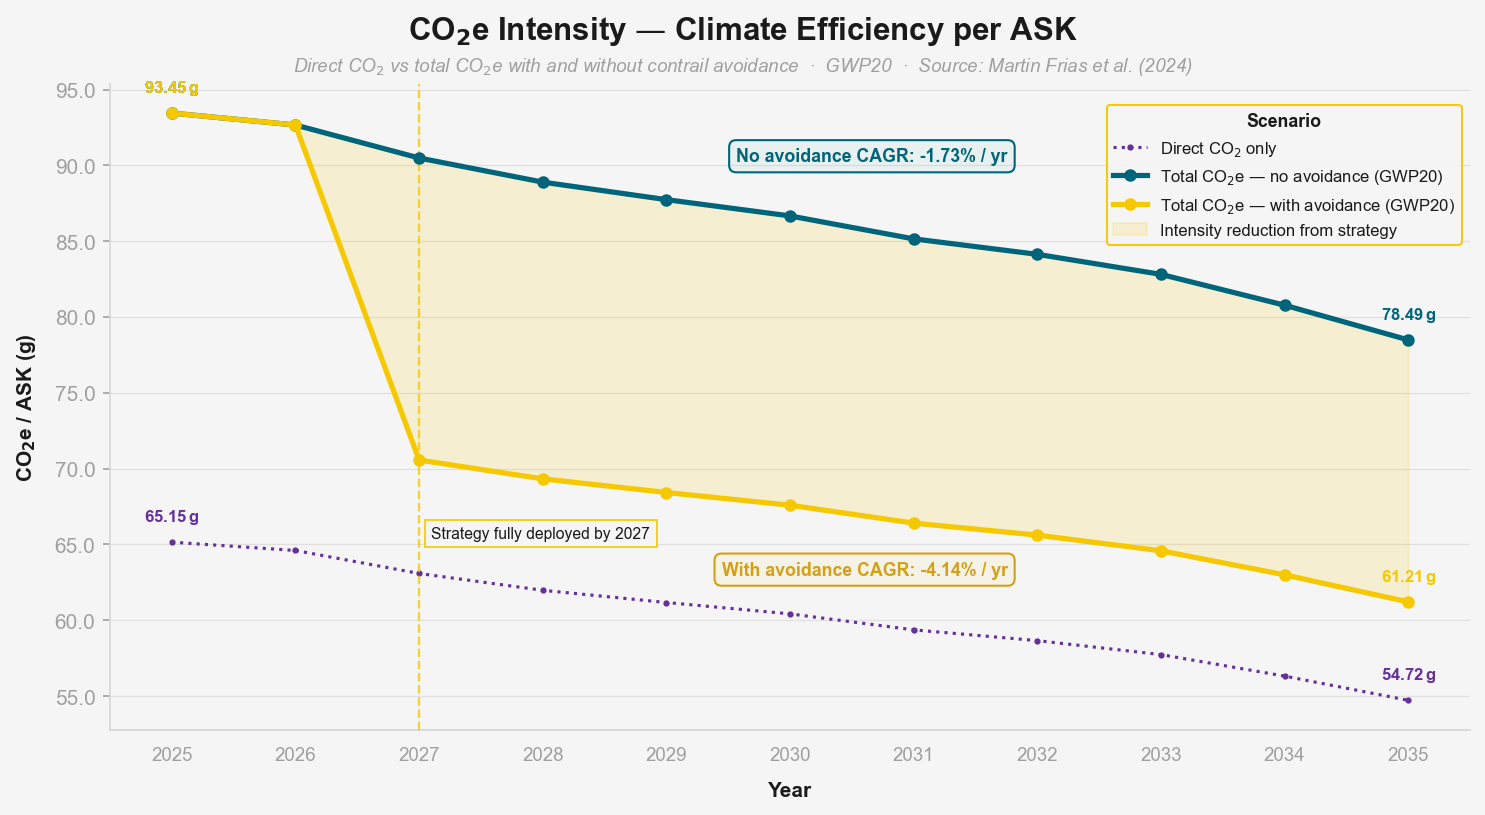

Saved → C5_co2eq_per_ask.pdf


In [ ]:
# ── C5. CO₂eq / ASK — Climate Intensity with Contrail Avoidance ──────────────

# ── A4. CO2 EMISSIONS TRAJECTORY ─────────────────────────────────────────────
SEATS = {
    'A319': 144, 'A320': 186, 'A321': 228,
    'A320Neo': 186, 'A321Neo': 236, 'B38M': 200
}

seats_by_year = (
    df.groupby(['year','aircraft_type_icao'])
    .agg(flights=('flights_count','sum')).reset_index()
    .assign(seats=lambda x: x['aircraft_type_icao'].map(SEATS).fillna(180))
    .assign(seat_flights=lambda x: x['flights'] * x['seats'])
    .groupby('year')
    .apply(lambda g: g['seat_flights'].sum() / g['flights'].sum())
    .rename('avg_seats')
)

annual_co2 = df.groupby('year').agg(
    total_flights         = ('flights_count',         'sum'),
    total_co2             = ('Total_CO2_sum',          'sum'),
    lto_co2               = ('LTO_CO2_sum',            'sum'),
    ccd_co2               = ('CCD_CO2_sum',            'sum'),
    total_distance_km_sum = ('total_distance_km_sum',  'sum'),
).reset_index()

annual_co2 = annual_co2.join(seats_by_year, on='year')
annual_co2['total_ask']   = annual_co2['total_distance_km_sum'] * annual_co2['avg_seats']
annual_co2['co2_per_ask'] = annual_co2['total_co2'] / annual_co2['total_ask']


# Merge ASK into annual contrail dataframe
annual_c = annual.copy()
annual_c = annual_c.join(annual_co2.set_index('year')[['total_ask']], on='year')

# g CO₂e / ASK for each scenario  (kg → g: ×1000, ASK in km·seats)
annual_c['intensity_co2_only']      = annual_c['CO2_only_Mt']      * 1e9 / annual_c['total_ask']
annual_c['intensity_no_avoidance']  = annual_c['total_no_avoidance_Mt']  * 1e9 / annual_c['total_ask']
annual_c['intensity_with_avoidance']= annual_c['total_with_avoidance_Mt']* 1e9 / annual_c['total_ask']

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.set_axisbelow(True)
ax.grid(True, color='#E0E0E0', linewidth=0.6, zorder=0)
ax.grid(False, axis='x')

# Direct CO₂ only (reference)
ax.plot(years, annual_c['intensity_co2_only'] * 1000,
        color=IC['violet'], lw=1.5, linestyle=':', marker='.', ms=4, zorder=2,
        label=r'Direct CO$_2$ only')

# No avoidance
ax.plot(years, annual_c['intensity_no_avoidance'] * 1000,
        color=VY['deep_teal'], lw=2.5, marker='o', ms=5, zorder=4,
        label=f'Total CO$_2$e — no avoidance (GWP{TIME_HORIZON})')
# ax.fill_between(years,
#                 annual_c['intensity_co2_only'] * 1000,
#                 annual_c['intensity_no_avoidance'] * 1000,
#                 color=VY['teal'], alpha=0.10, zorder=1)

# With avoidance
ax.plot(years, annual_c['intensity_with_avoidance'] * 1000,
        color=VY['yellow'], lw=2.5, marker='o', ms=5, zorder=4,
        label=f'Total CO$_2$e — with avoidance (GWP{TIME_HORIZON})')
ax.fill_between(years,
                annual_c['intensity_with_avoidance'] * 1000,
                annual_c['intensity_no_avoidance'] * 1000,
                color=VY['yellow'], alpha=0.15, zorder=1,
                label='Intensity reduction from strategy')

# Deployment line
ax.axvline(AVOIDANCE_START_YEAR, color=VY['yellow'],
           lw=1.1, ls='--', alpha=0.8, zorder=3)
ax.text(AVOIDANCE_START_YEAR + 0.1,
        annual_c['intensity_no_avoidance'].max() * 1000 * 0.7,
        f'Strategy fully deployed by {AVOIDANCE_START_YEAR}',
        fontsize=7.5, color=VY['dark'],
        bbox=dict(facecolor=VY['bg'], edgecolor=VY['yellow'], pad=3, lw=0.8))

# First & last annotations — same style as A4 right panel
for col, color in [
    ('intensity_no_avoidance',   VY['deep_teal']),
    ('intensity_with_avoidance', VY['yellow']),
    ('intensity_co2_only',       IC['violet']),
]:
    for idx in [0, -1]:
        val  = annual_c[col].iloc[idx] * 1000
        year = annual_c['year'].iloc[idx]
        ax.annotate(rf"{val:.2f}$\,$g",
                    xy=(year, val),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=8, color=color, fontweight='bold')

# CAGR boxes
cagr_no_av = (annual_c['intensity_no_avoidance'].iloc[-1] /
              annual_c['intensity_no_avoidance'].iloc[0]) ** (1/10) - 1
cagr_av    = (annual_c['intensity_with_avoidance'].iloc[-1] /
              annual_c['intensity_with_avoidance'].iloc[0]) ** (1/10) - 1

ax.annotate(f"No avoidance CAGR: {cagr_no_av:+.2%} / yr",
            xy=(0.66, 0.88), xycoords='axes fraction',
            ha='right', fontsize=8.5, color=VY['deep_teal'], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor=(*mcolors.to_rgb(IC['teal']), 0.05),
                      edgecolor=VY['deep_teal'], lw=1))
ax.annotate(f"With avoidance CAGR: {cagr_av:+.2%} / yr",
            xy=(0.66, 0.24), xycoords='axes fraction',
            ha='right', fontsize=8.5, color=VY['gold'], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor=(*mcolors.to_rgb(VY['yellow']), 0.05),
                      edgecolor=VY['gold'], lw=1))

ax.set_xlabel('Year', labelpad=8)
ax.set_ylabel(rf'CO$\mathbf{{_2}}$e / ASK (g)', labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax.set_xticks(years)
ax.set_xticklabels(years, fontsize=9)
ax.tick_params(axis='x', length=0, pad=8)
ax.spines['left'].set_color(VY['light_grey'])
ax.spines['bottom'].set_color(VY['light_grey'])

leg = ax.legend(loc='upper right', fontsize=8,
                title='Scenario', title_fontsize=8.5, bbox_to_anchor=(1,.98))
style_legend(leg)

styled_title(fig,
    rf'CO$\mathbf{{_2}}$e Intensity — Climate Efficiency per ASK',
    f'Direct CO$_2$ vs total CO$_2$e with and without contrail avoidance  ·  GWP{TIME_HORIZON}  ·  Source: Martin Frias et al. (2024)')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('../0. Data/Figures/C5_co2eq_per_ask_202_fleet.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → C5_co2eq_per_ask.pdf')

---

In [35]:
print(f"Average number of flights to increase per year: {annual['flights'][1:].diff().mean():.0f}")
print('\n── Final reduction in 2035 (in fact, every year based on calculation) from contrail avoidance strategy ──────────────────')
reduction = (annual.iloc[-1]['total_no_avoidance_Mt'] - 
             annual.iloc[-1]['total_with_avoidance_Mt']) / \
             annual.iloc[-1]['total_no_avoidance_Mt']
print(f"{reduction:.1%}")

print(f"Average warming avoided yearly: {annual[2:].warming_avoided_Mt.mean():.2f} Mt CO₂e")

Average number of flights to increase per year: 10229

── Final reduction in 2035 (in fact, every year based on calculation) from contrail avoidance strategy ──────────────────
22.0%
Average warming avoided yearly: 1.13 Mt CO₂e
